In [1]:
import pandas as pd
import numbers as np
import matplotlib.pyplot as plt
import seaborn as sns

 ### Loading Our DataSet

In [2]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [3]:
df.shape

(2240, 22)

In [4]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Pre-Processing

### 1. Handel Missing Values

In [5]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [6]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

### 2. Feature Engineering

We will add an $Age$ column

The intuition behind this is that we have birth_year, and instead of the year of birth the age of customer would be more useful for us.

In [7]:
df["Age"] = 2026-df["Year_Birth"]

In [8]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


We will create another columns $Customer_Tenure_Days$ and we will fill the values by taking reference from the max join date

In [9]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

refrence_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


Another feature that I would like to add is $Spending$

Spending = wines + fruits + meat + fish + gold + sweet

In [11]:
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + \
                        df["MntSweetProducts"] + df["MntGoldProds"]

Next feature that we will create will be $Total Children$

Total_Children = teen + kids

In [12]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [13]:
# Education
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

Instead of so many categories we will convert it into three categories: Postgraduate, Undergraduate, Graduate

In [14]:
df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [15]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [16]:
# Marital Status
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [17]:
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [18]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### 3. Drop Columns

In [19]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_Children', 'Living_With'],
      dtype='str')

In [20]:
cols = ["ID", "Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]

cols_to_drop = cols + spending_cols

df_clean = df.drop(columns=cols_to_drop)

In [21]:
df_clean.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


In [22]:
df_clean.shape

(2240, 15)

### 3. Handling Outliers

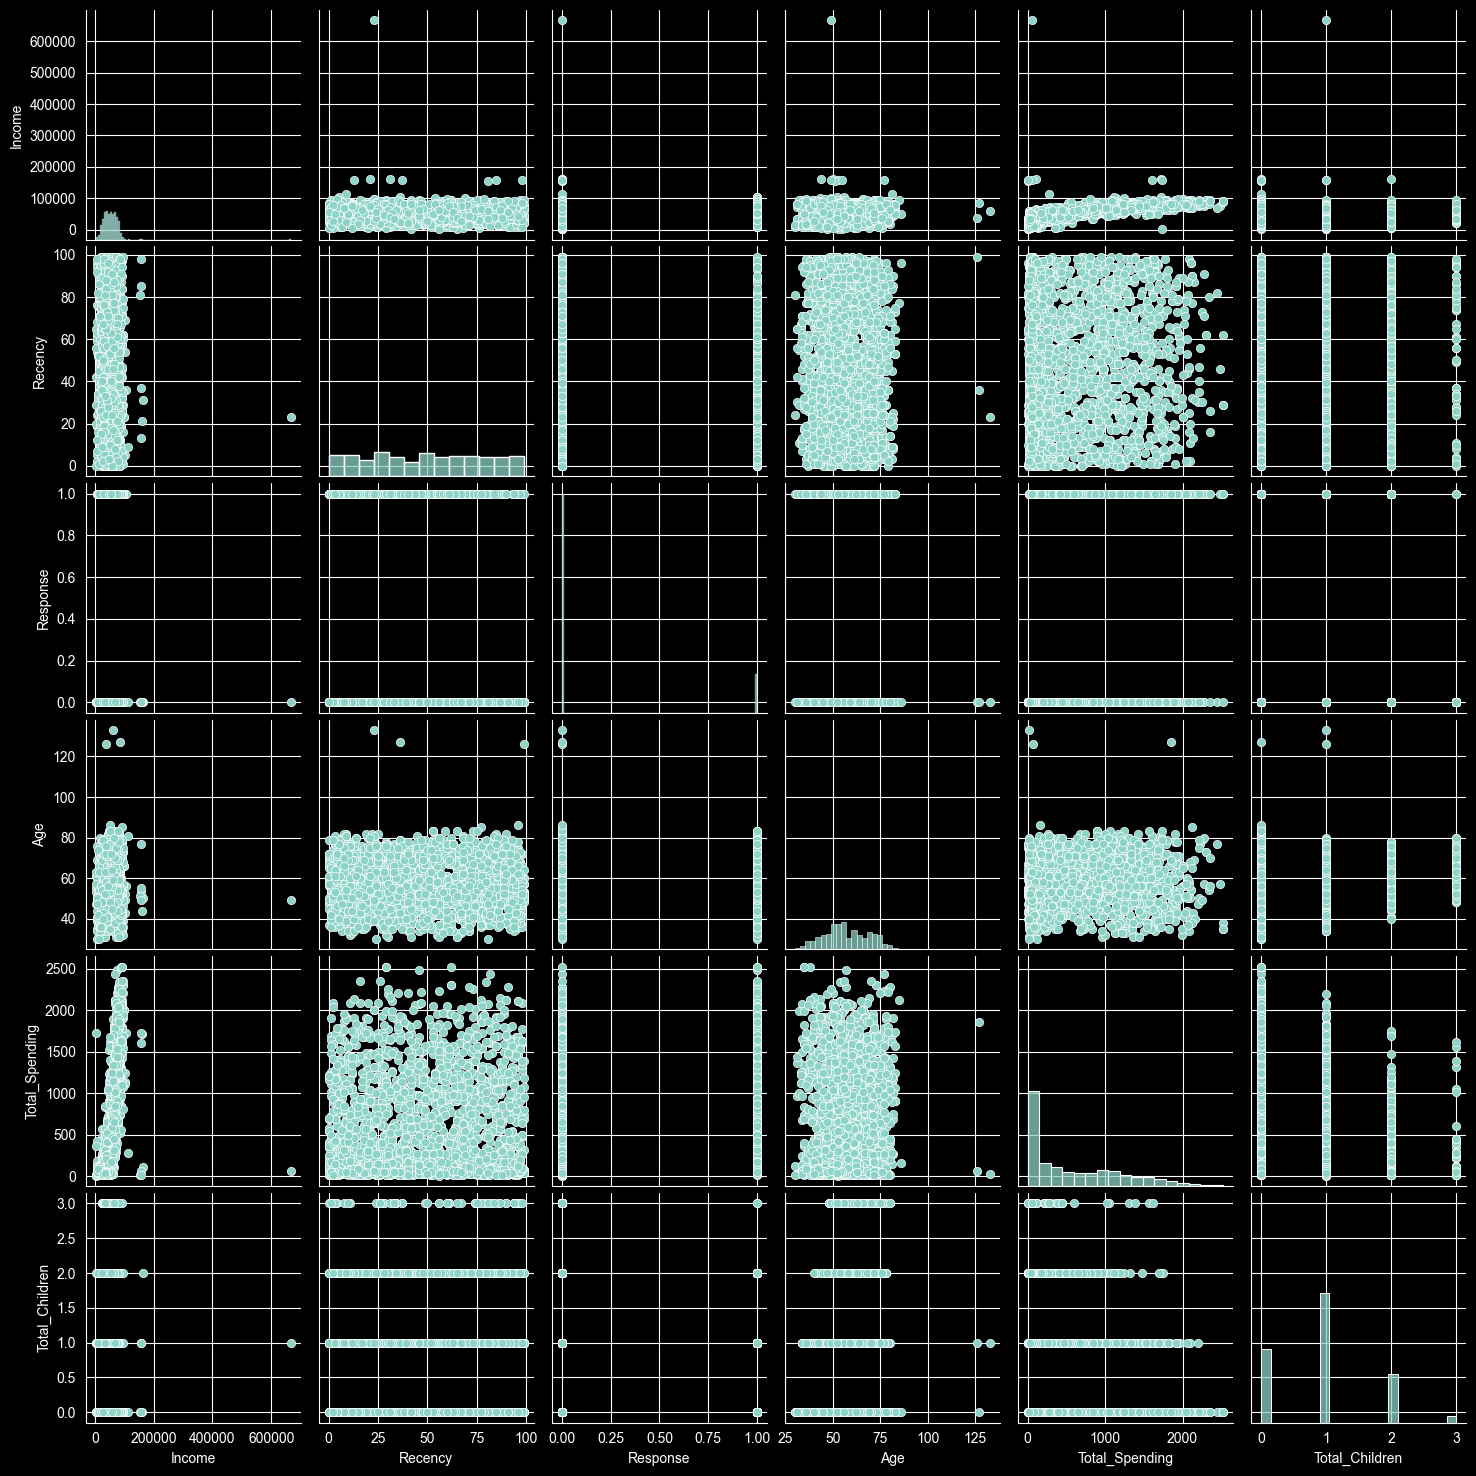

In [23]:
# Relative plot of some features
cols = ["Income", "Recency", "Response", "Age","Total_Spending", "Total_Children"]

# Pair plots
sns.pairplot(df_clean[cols])

Income : remove more than 60,000+

Age: keep only below 90

In [24]:
df_clean = df_clean[(df_clean["Age"] < 90)]
df_clean = df_clean[(df_clean["Income"] < 600_000)]

### 4. HeatMap

In [25]:
corr = df_clean.corr(numeric_only=True)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

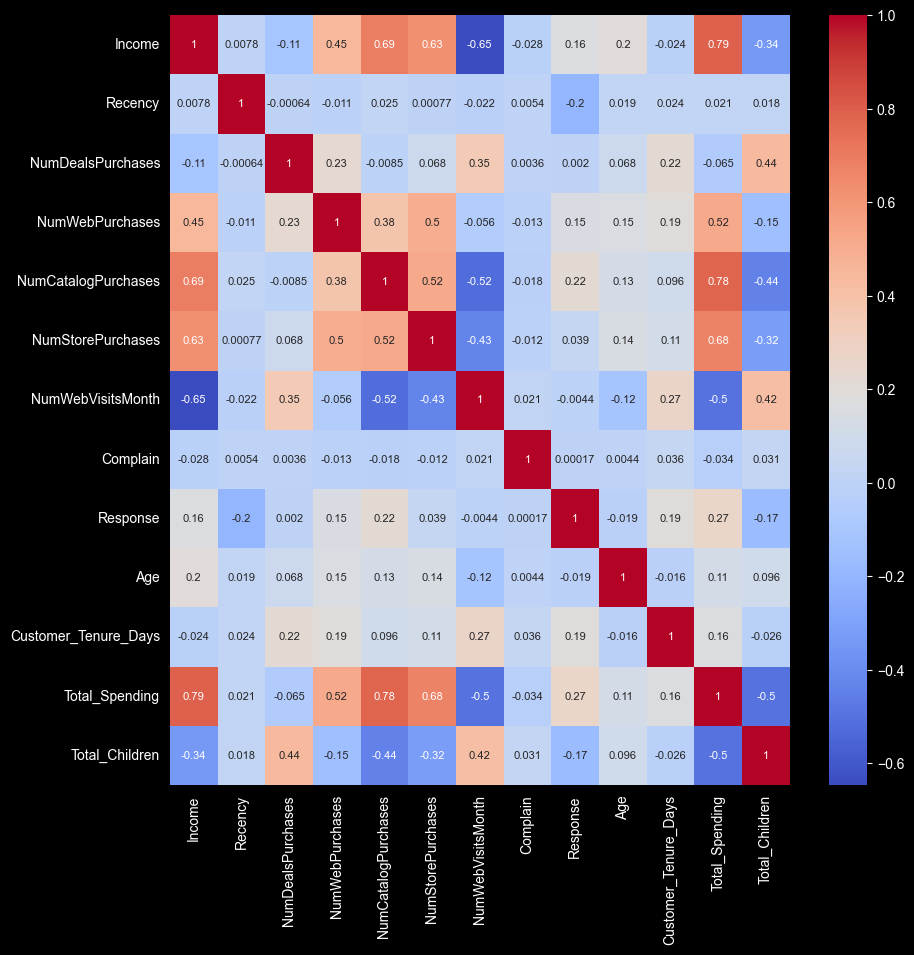

In [26]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap = "coolwarm", annot_kws={"size": 8})

plt.tight_layout

- 0.79 => Income & Total_Spending
- 0.69 => Income & NumOfCatalogPurchase
- 0.63 => Income & NumOfStorePurchases
- -0.65 => Income & WebSiteVisits
- 0.78 => Spending & CataloguePurchase
- 0.68 => spending & StorePurchase

### 5. Feature Encoding

In [27]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [28]:
df_clean.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_Children',
       'Living_With'],
      dtype='str')

In [29]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_clean[cat_cols])

In [30]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index = df_clean.index)

In [31]:
df_encoded = pd.concat([df_clean.drop(columns=cat_cols) , enc_df], axis=1)

### 6. Scaling

In [32]:
from sklearn.preprocessing import StandardScaler
X = df_encoded

In [33]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### 7. Visualize

In [34]:
X_scaled.shape

(2236, 18)

In [35]:
from sklearn.decomposition import PCA

In [36]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


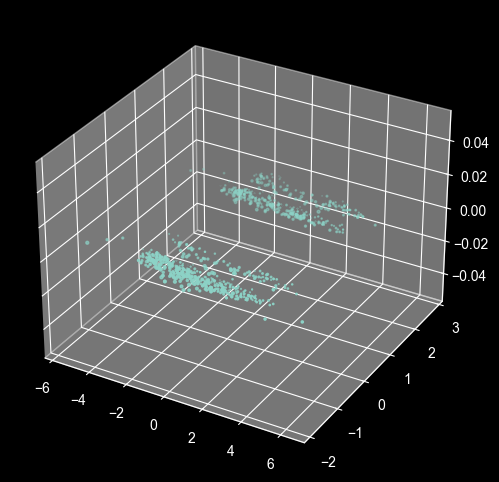

In [37]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111, projection='3d')
plt.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

In [38]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K-value

### 1. Elbow Method

In [39]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [40]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [41]:
knee = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.elbow

In [42]:
print("Best k:", optimal_k)

Best k: 4


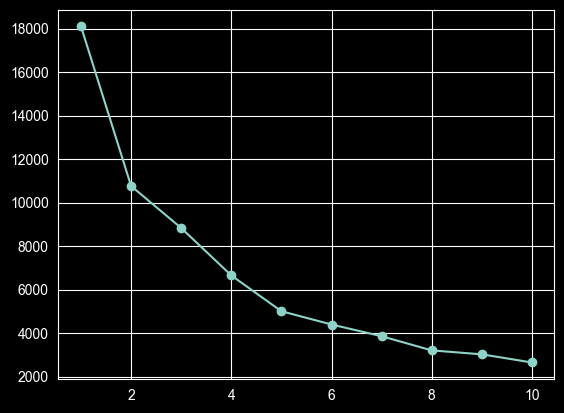

In [43]:
# Plot
plt.plot(range(1,11), wcss, marker='o')

### 2. Silhoette Score

In [44]:
from sklearn.metrics import silhouette_score

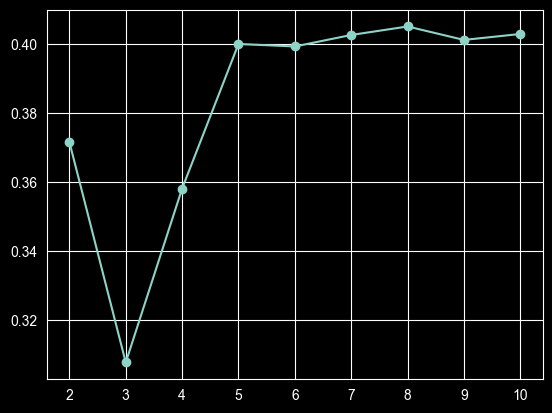

In [45]:
scores =[]

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

# Plot
plt.plot(range(2,11), scores, marker='o')

Text(0, 0.5, 'Silhouette Score')

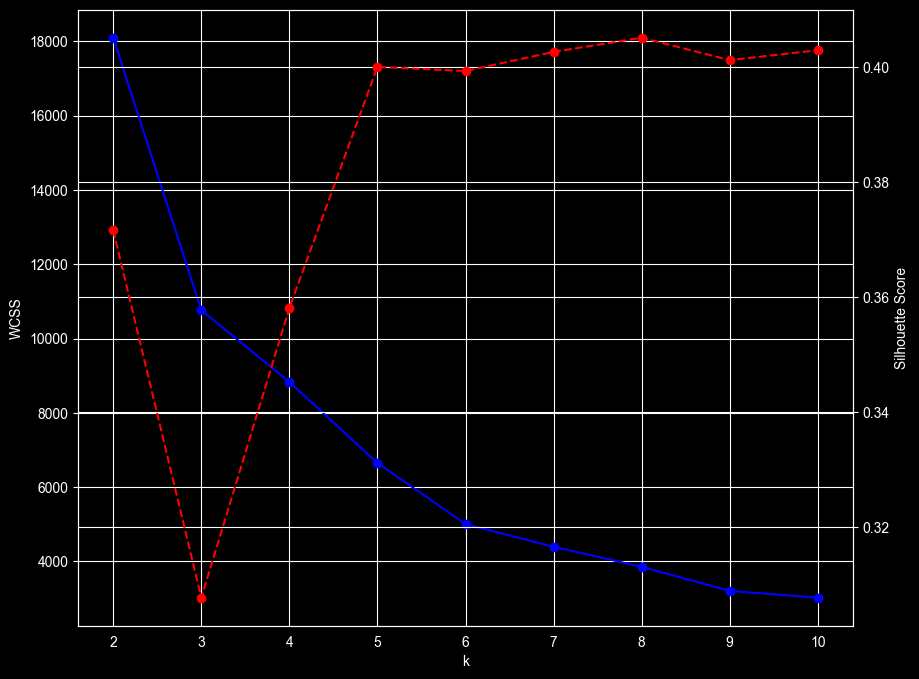

In [46]:
# Combined plot
k_range = range(2,11)

fig, ax1 = plt.subplots(figsize=(10,8))

ax1.plot(k_range, wcss[:len(k_range)], marker='o', color = 'blue')
ax1.set_xlabel('k')
ax1.set_ylabel('WCSS')

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker='o', color = 'red', linestyle = '--')
ax2.set_ylabel('Silhouette Score')

k=4 is the optimal value as through graph we can clearly see that bot the curves interscet near k

# Clustering

### K_means

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


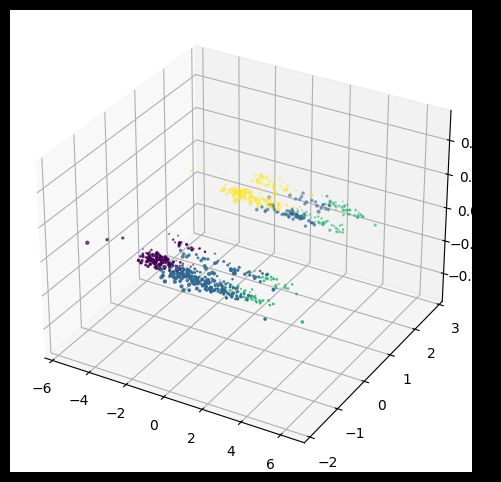

In [47]:
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
plt.style.use('default')
ax = fig.add_subplot(111, projection='3d')
plt.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels)

### Agglomerative Clustering

In [48]:
from sklearn.cluster import AgglomerativeClustering

In [49]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agg = agg_clf.fit_predict(X_pca)

C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\collections.py:999: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


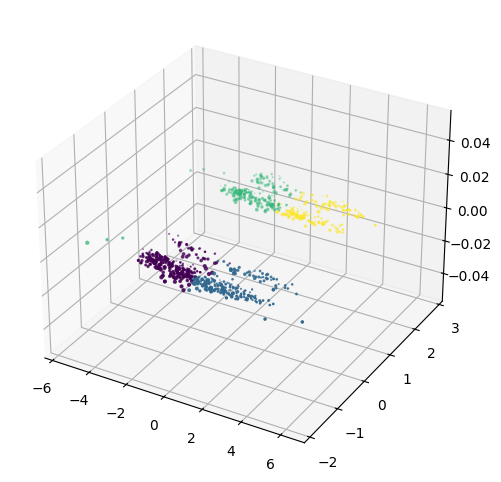

In [50]:
fig = plt.figure(figsize=(8,6))
plt.style.use('default')

ax = fig.add_subplot(111, projection='3d')
plt.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c = labels_agg)

# Characterization Of Clusters

In [51]:
X["Cluster"] = labels_agg

In [52]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,Cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='Cluster', ylabel='count'>

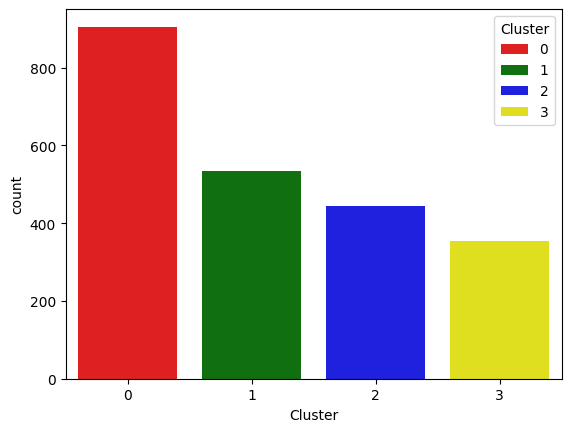

In [53]:
pal = ["red", "green", "blue", "yellow"]

sns.countplot(x=X["Cluster"], palette= pal, hue=X["Cluster"])

<Axes: xlabel='Total_Spending', ylabel='Income'>

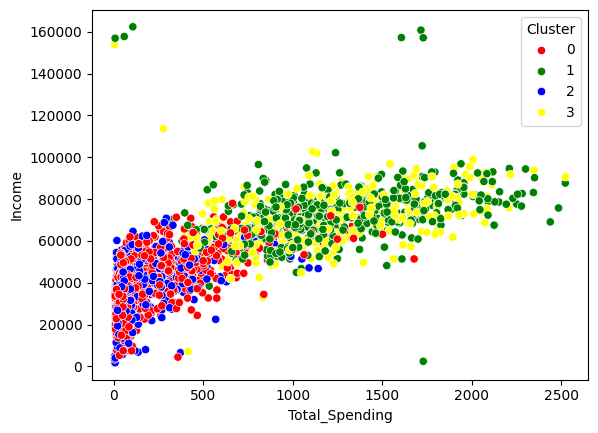

In [54]:
# Income and Spending patterns

sns.scatterplot(x=X["Total_Spending"], y=X["Income"], hue=X["Cluster"], palette=pal)

- Cluster 0(Red):    low/ moderate Income. low/moderate spending
- Cluster 1(Green):  High Income & High Spending
- Cluster 3(Blue):   Low Income & Low Spending
- Cluster 4(Yellow): Moderate-High Income & Hight Spending


### Cluster Summary

In [55]:
cluster_summary = X.groupby("Cluster").mean()
cluster_summary

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
Cluster,,,,,,,,,,,,,,,,,,
0,39680.580110,48.914917,2.594475,3.153591,0.969061,4.143646,6.307182,0.011050,0.076243,55.669613,342.939227,221.955801,1.243094,0.514917,0.338122,0.146961,0.000000,1.000000
1,72808.445693,49.202247,1.958801,5.687266,5.498127,8.659176,3.580524,0.005618,0.166667,59.492509,369.720974,1236.588015,0.511236,0.471910,0.455056,0.073034,0.000000,1.000000
2,36960.143018,48.319820,2.594595,2.713964,0.837838,3.623874,6.659910,0.011261,0.141892,55.691441,338.781532,165.702703,1.272523,0.488739,0.378378,0.132883,0.993243,0.006757
3,70722.681303,50.504249,1.855524,5.790368,5.014164,8.430595,3.728045,0.005666,0.320113,58.932011,376.280453,1190.385269,0.461756,0.541076,0.390935,0.067989,1.000000,0.000000


C:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


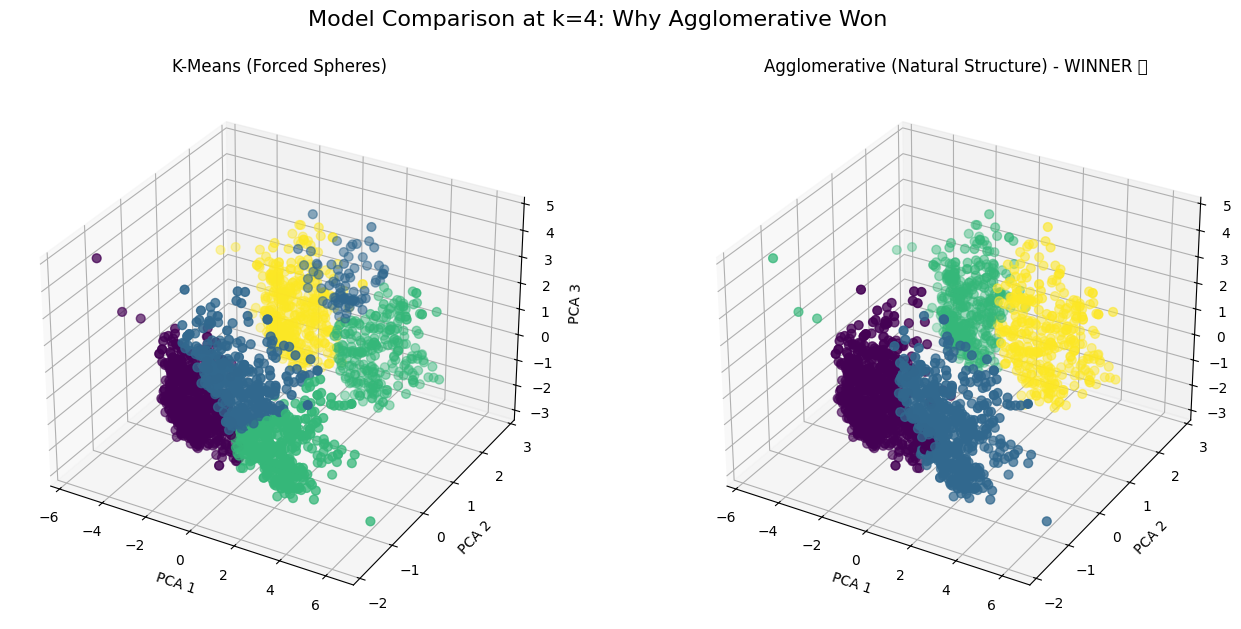

In [56]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
import pandas as pd

# 1. Run Both Models at k=4
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

agg = AgglomerativeClustering(n_clusters=4)
labels_agg = agg.fit_predict(X_pca)

# 2. Plot Side-by-Side
fig = plt.figure(figsize=(16, 7))

# Plot 1: K-Means
ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans, cmap='viridis', s=40)
ax1.set_title("K-Means (Forced Spheres)")
ax1.set_xlabel('PCA 1'); ax1.set_ylabel('PCA 2'); ax1.set_zlabel('PCA 3')

# Plot 2: Agglomerative (The Winner)
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg, cmap='viridis', s=40)
ax2.set_title("Agglomerative (Natural Structure) - WINNER 🏆")
ax2.set_xlabel('PCA 1'); ax2.set_ylabel('PCA 2'); ax2.set_zlabel('PCA 3')

plt.suptitle(f"Model Comparison at k=4: Why Agglomerative Won", fontsize=16)
plt.show()